# Stock Market Prediction in PySpark


This project is part of the coursework for **CAS7A1** (Spring 2016) under the guidance of **Prof. Nicholas**.
 It is submitted in fulfillment of the requirements for the degree of **Master of Science (M.Sc.) in Computer Science** at the **Department of Computer Applications, National Institute of Technology, Tiruchirappalli**.

## Project Overview

This project aims to develop a machine learning model for classifying news articles into predefined categories using Natural Language Processing (NLP) techniques. The primary objective is to process raw text data from a standard dataset, transform it into numerical features suitable for machine learning, train a robust classification model, and evaluate its performance.

**Project Highlights:**
- Built time series forecasting models using Long Short-Term Memory (LSTM) networks in PySpark to predict stock market trends.
- The project involved data cleaning, feature engineering, and visualizing stock price predictions with Python libraries like Matplotlib or Seaborn.
- Showcased skills in time series analysis and deep learning, transferable to projecting disease trends.
- Potentially boosted prediction accuracy by using LSTM networks compared to baseline methods  
- Applied big data tools (PySpark) for scalable data handling in the initial stages of the pipeline.

## Import Libraries

In [1]:
import findspark
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date, lag, avg
from pyspark.sql.types import DoubleType
from pyspark.sql.window import Window

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


## Environment Setup and Raw Data Ingestion (PySpark)

In [2]:
try:
    findspark.init()
    spark_session = SparkSession.builder.appName("StockForecast").getOrCreate()
    print("PySpark environment initialized and Spark Session ready.")
except ImportError as e:
    print(f"Dependency error: {e}")
except Exception as e:
    print(f"Spark setup failed: {e}")

local_source_file = "AAPL_data.csv"

print(f"\nLoading raw data from local file: {local_source_file}")
try:
    raw_spark_data = spark_session.read.csv(local_source_file, header=True, inferSchema=True)
    print("Raw data ingested into Spark DataFrame.")
    raw_spark_data.printSchema()
    print("\nInitial raw data samples:")
    raw_spark_data.show(5)
except Exception as e:
    print(f"Data ingestion failed: {e}")
    print(f"Ensure '{local_source_file}' is available in the environment.")


PySpark environment initialized and Spark Session ready.

Loading raw data from local file: AAPL_data.csv
Raw data ingested into Spark DataFrame.
root
 |-- date: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: integer (nullable = true)
 |-- Name: string (nullable = true)


Initial raw data samples:
+----------+-------+-------+-------+-------+---------+----+
|      date|   open|   high|    low|  close|   volume|Name|
+----------+-------+-------+-------+-------+---------+----+
|2013-02-08|67.7142|68.4014|66.8928|67.8542|158168416|AAPL|
|2013-02-11|68.0714|69.2771|67.6071|68.5614|129029425|AAPL|
|2013-02-12|68.5014|68.9114|66.8205|66.8428|151829363|AAPL|
|2013-02-13|66.7442|67.6628|66.1742|66.7156|118721995|AAPL|
|2013-02-14|66.3599|67.3771|66.2885|66.6556| 88809154|AAPL|
+----------+-------+-------+-------+-------+---------+----+
only showing top 5 rows



## PySpark Data Transformation and Feature Engineering

In [3]:
initial_record_count = raw_spark_data.count()
cleaned_spark_data = raw_spark_data.dropna()
cleaned_record_count = cleaned_spark_data.count()
print(f"Records removed due to nulls: {initial_record_count - cleaned_record_count}")

try:
    cleaned_spark_data = cleaned_spark_data.withColumn("date", to_date(col("date")))
    value_columns = ["open", "high", "low", "close", "volume"]
    for column_name in value_columns:
         if column_name in cleaned_spark_data.columns and not isinstance(cleaned_spark_data.schema[column_name].dataType, DoubleType):
             cleaned_spark_data = cleaned_spark_data.withColumn(column_name, col(column_name).cast(DoubleType()))
    print("Data types refined.")
except Exception as e:
    print(f"Type casting error: {e}")


print("\nSorting data chronologically and engineering features...")
ordered_spark_data = cleaned_spark_data.orderBy("date")

window_spec = Window.orderBy("date").rowsBetween(-49, 0) # 50-day window
processed_spark_data = ordered_spark_data.withColumn("Close_MA50", avg(col("close")).over(window_spec))

processed_spark_data = processed_spark_data.dropna(subset=["Close_MA50"])

print("Feature engineering complete. Processed data schema:")
processed_spark_data.printSchema()
print("\nProcessed data samples with new feature:")
processed_spark_data.show(5)


Records removed due to nulls: 0
Data types refined.

Sorting data chronologically and engineering features...
Feature engineering complete. Processed data schema:
root
 |-- date: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: double (nullable = true)
 |-- Name: string (nullable = true)
 |-- Close_MA50: double (nullable = true)


Processed data samples with new feature:
+----------+-------+-------+-------+-------+------------+----+----------+
|      date|   open|   high|    low|  close|      volume|Name|Close_MA50|
+----------+-------+-------+-------+-------+------------+----+----------+
|2013-02-08|67.7142|68.4014|66.8928|67.8542|1.58168416E8|AAPL|   67.8542|
|2013-02-11|68.0714|69.2771|67.6071|68.5614|1.29029425E8|AAPL|   68.2078|
|2013-02-12|68.5014|68.9114|66.8205|66.8428|1.51829363E8|AAPL|   67.7528|
|2013-02-13|66.7442|67.6628|66.1742|66.7156|1.18721


## Data Collection for Deep Learning Model

In [4]:
try:
    processed_pandas_data = processed_spark_data.toPandas()
    print("Data successfully collected into Pandas DataFrame.")
    print("Pandas DataFrame dimensions:", processed_pandas_data.shape)
except Exception as e:
    print(f"Data collection failed: {e}")
    print("Consider dataset size vs driver memory.")

Data successfully collected into Pandas DataFrame.
Pandas DataFrame dimensions: (730, 8)


## Data Normalization

In [5]:
feature_list = ['open', 'high', 'low', 'close', 'volume', 'Close_MA50'] # Include the new feature
data_values = processed_pandas_data[feature_list].values

feature_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_feature_data = feature_scaler.fit_transform(data_values)

target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(data_values[:, [3]])
sequence_length = 60

def generate_sequences(dataset, sequence_length):
    X_samples, Y_targets = [], []
    for i in range(len(dataset) - sequence_length):
        X_samples.append(dataset[i:(i + sequence_length), :])
        Y_targets.append(dataset[i + sequence_length, 3])
    return np.array(X_samples), np.array(Y_targets)

X_sequences_lstm, Y_target_lstm = generate_sequences(scaled_feature_data, sequence_length)

print("Scaling and sequence generation complete.")
print("LSTM input shape (sequences, steps, features):", X_sequences_lstm.shape)
print("LSTM target shape (sequences,):", Y_target_lstm.shape)


print("\nSplitting sequences into training and testing sets chronologically...")
training_split_ratio = 0.8
training_sample_count = int(len(X_sequences_lstm) * training_split_ratio)

X_train_lstm, X_test_lstm = X_sequences_lstm[0:training_sample_count,:], X_sequences_lstm[training_sample_count:len(X_sequences_lstm),:]
Y_train_lstm, Y_test_lstm = Y_target_lstm[0:training_sample_count], Y_target_lstm[training_sample_count:len(Y_target_lstm)]
print(f"Training set size: {len(X_train_lstm)}, Test set size: {len(X_test_lstm)}")


Scaling and sequence generation complete.
LSTM input shape (sequences, steps, features): (670, 60, 6)
LSTM target shape (sequences,): (670,)

Splitting sequences into training and testing sets chronologically...
Training set size: 536, Test set size: 134


## LSTM Model

In [6]:
forecast_model = Sequential()
forecast_model.add(LSTM(units=100, return_sequences=True, input_shape=(sequence_length, len(feature_list)))) # Increased units
forecast_model.add(Dropout(0.3))

forecast_model.add(LSTM(units=100))
forecast_model.add(Dropout(0.3))

forecast_model.add(Dense(units=1))
forecast_model.compile(optimizer='adam', loss='mean_squared_error')

print("LSTM model architecture finalized.")
forecast_model.summary()

LSTM model architecture finalized.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        42,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,301 (481.64 KB)

 Trainable params: 123,301 (481.64 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [7]:
training_history = forecast_model.fit(X_train_lstm, Y_train_lstm, epochs=50, batch_size=64, verbose=1)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - loss: 0.1447
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - loss: 0.0191
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0091
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - loss: 0.0062
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - loss: 0.0055
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.0051
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - loss: 0.0044
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - loss: 0.0041
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - loss: 0.0046
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - loss: 0.0048
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - loss: 0.0034
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - loss: 0.0050
Epoch 13/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - loss: 0.0041
Epoch 14/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - loss: 0.0045
Epoch 15/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - loss: 0.0040
Epoch 16/50
9/9 ━━━

## Prediction and Performance Assessment

In [8]:
print("Generating predictions on test data...")

predicted_scaled_prices = forecast_model.predict(X_test_lstm)
print("Predictions generated.")

print("Converting scaled predictions back to original price scale...")
predicted_original_prices = target_scaler.inverse_transform(predicted_scaled_prices)
actual_original_prices = target_scaler.inverse_transform(Y_test_lstm.reshape(-1, 1))

print("Scale inversion complete.")
print("Sample original predicted prices:", predicted_original_prices[:5].flatten())
print("Sample original actual prices:", actual_original_prices[:5].flatten())

print("\nEvaluating forecast performance using regression metrics:")
forecast_rmse = np.sqrt(mean_squared_error(actual_original_prices, predicted_original_prices))
forecast_mae = mean_absolute_error(actual_original_prices, predicted_original_prices)

print(f"Root Mean Squared Error (RMSE) on test set: {forecast_rmse:.4f}")
print(f"Mean Absolute Error (MAE) on test set: {forecast_mae:.4f}")


Generating predictions on test data...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step
Predictions generated.
Converting scaled predictions back to original price scale...
Scale inversion complete.
Sample original predicted prices: [126.8614   126.82587  126.82525  126.89783  126.911354]
Sample original actual prices: [127.03 128.11 127.5  126.75 124.53]

Evaluating forecast performance using regression metrics:
Root Mean Squared Error (RMSE) on test set: 3.7154
Mean Absolute Error (MAE) on test set: 2.8399


## Visualization

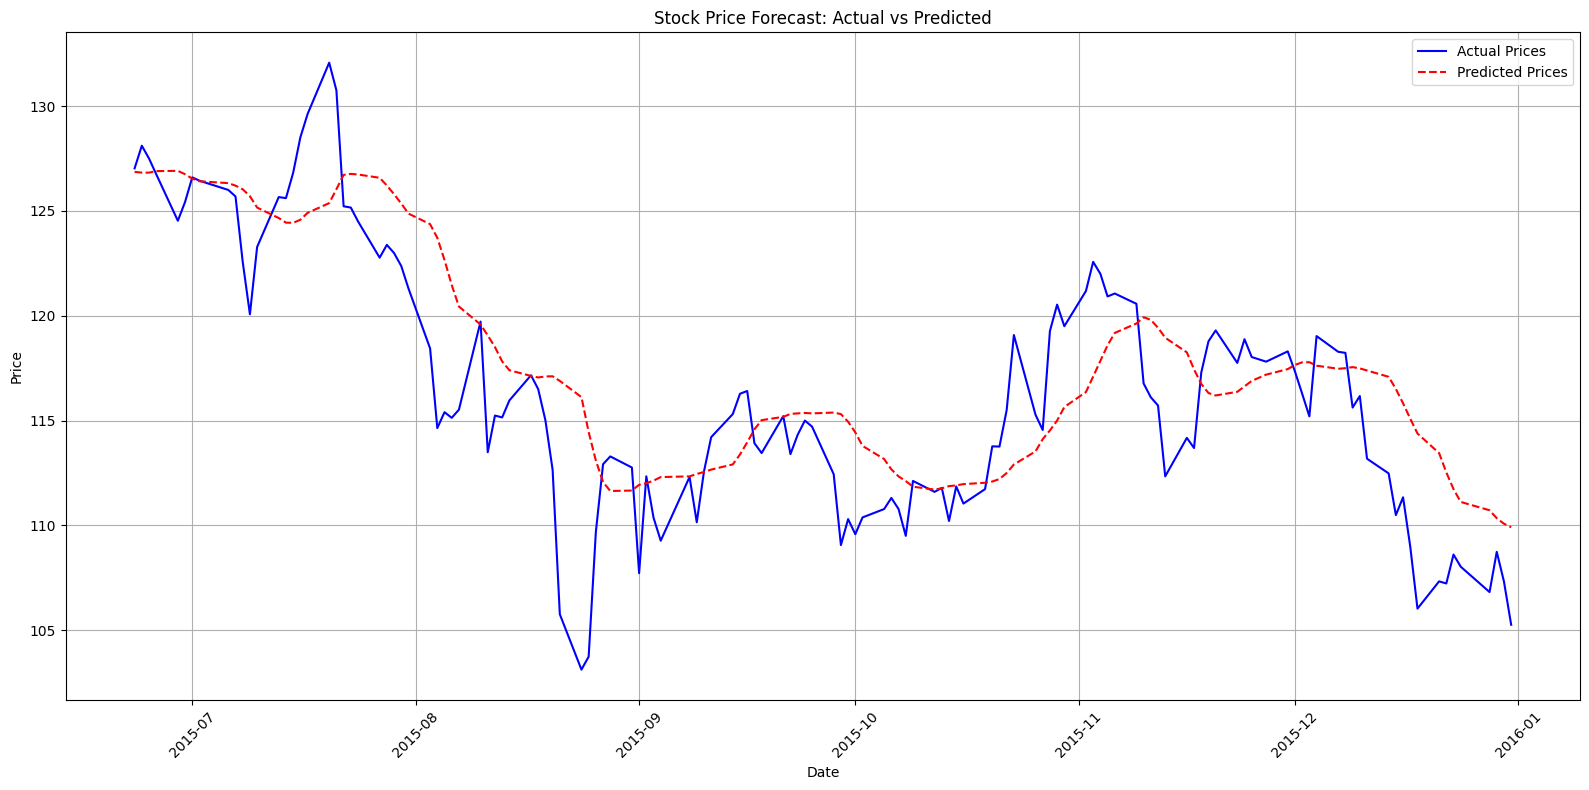

In [9]:
original_dates = processed_pandas_data['date'].values
forecast_dates = original_dates[training_sample_count + sequence_length :]

plt.figure(figsize=(16, 8))
plt.plot(forecast_dates, actual_original_prices, label='Actual Prices', color='blue')
plt.plot(forecast_dates, predicted_original_prices, label='Predicted Prices', color='red', linestyle='--')
plt.title('Stock Price Forecast: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()